# Binh and Korn function

---
Description:

- Optimization (min)
- Multi-objective (2)
- Constraints (2)
---


The goal is to **minimize** the following equations:

\begin{cases}
      f_{1}\left(x,y\right) = 4x^{2} + 4y^{2}, \\
      f_{2}\left(x,y\right) = \left(x - 5\right)^{2} + \left(y - 5\right)^{2} \\
\end{cases}

subject to constraints:

\begin{cases}
      c_{1}\left(x,y\right) = \left(x - 5\right)^{2} + y^{2} \leq 25, \\
      c_{2}\left(x,y\right) = \left(x - 8\right)^{2} + \left(y + 3\right)^{2} \geq 7.7 \\
\end{cases}

where:

\begin{cases}
      0\le x \le 5, \\
      0\le y \le 3. \\
\end{cases}

The Pareto-optimal solutions are constituted by solutions:
    $ x=y ∈ [0.0, 3.0] \text{  and  } x ∈ [3.0, 5.0], y=3.0.$

### First we import Python libraries and set up the directory of our code.

In [1]:
import os, sys

import numpy as np
from matplotlib import pyplot as plt

PROJECT_DIR = os.path.abspath('..')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

### Here we import all our custom GA code.

In [2]:
# Import main classes.
from pygenalgo.genome.gene import Gene
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.utils.utilities import cost_function, np_pareto_front
from pygenalgo.engines.multi_objective_ga import MultiObjectiveGA, RunConfig

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.blend_crossover import BlendCrossover

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.random_mutator import RandomMutator

# Import Selection Operator(s).
from pygenalgo.operators.selection.pareto_front_selector import ParetoFrontSelector

### Define the multi-objective function, which plays the role of the 'fitness' function.

We use a combination of the **weighted sum** and **penalty methods**.

In [3]:
# Multi-objective function.
@cost_function(minimize=True)
def fun_binh_korn(individual: Chromosome):

    # Extract the data values as
    # 'x' and 'y' for parsimony.
    x, y = individual.values()

    # Compute each objective function.
    f1: float = 4.0 * (x**2 + y**2)
    f2: float = (x - 5.0)**2 + (y - 5.0)**2

    # Compute the constraints.
    c1: float = max(0.0, (x - 5.0)**2 + y*y - 25.0)**2         # <= 0.0
    c2: float = min(0.0, (x - 8.0)**2 + (y + 3.0)**2 - 7.7)**2 # >= 0.0

    # Compute the penalty.
    penalty: float = c1 + c2

    return (penalty, f1, f2), False
# _end_def_

Then we set the GA parameters, such as the genes, the number of chromosomes, etc. Note that in this case the genes have the same
range so we define a single random function, set by 'boundary_xy'. Moreover, we set the parameters for the GA engine.

In [4]:
# Random number generator.
rng = np.random.default_rng()

# Random function that enforce the boundaries in x/y.
boundary_x = lambda: rng.uniform(0.0, 5.0)
boundary_y = lambda: rng.uniform(0.0, 3.0)

# Define the number of chromosomes.
n_pop = 100

# Initial population.
population = [Chromosome([Gene(boundary_x(), boundary_x),
                          Gene(boundary_y(), boundary_y)], None, True)
              for i in range(n_pop)]

# Create the MultiObjectiveGA object that will carry on the optimization.
test_GA = MultiObjectiveGA(initial_pop=population,
                           fit_func=fun_binh_korn,
                           select_op=ParetoFrontSelector(),
                           mutate_op=RandomMutator(),
                           crossx_op=BlendCrossover(lower_lim=[0.0, 0.0],
                                                    upper_lim=[5.0, 3.0]))

### Optimization process.

Here we call the GA object (either directly, or through the method run()). We set a number of parameter, such as the maximum iterations (i.e. epochs), tolerance for the fitness convergences, etc.

In [5]:
test_GA(config=RunConfig(epochs=250, elitism=True, verbose=False))

08/27/2026 10:52:32 INFO: Initial Avg. Fitness = [ -1.309  -40.0255 -22.9859]
08/27/2026 10:52:32 INFO: Final Avg. Fitness = [ -0.2606 -45.9836 -16.5812]


Elapsed time: 0.315 seconds.


### Visualize the adapted probabilities.

In [6]:
if len(test_GA.stats["prob_crossx"]) > 1:
    plt.plot(test_GA.stats["prob_crossx"],
             'ro:', markersize=5, label="crossover")

    plt.plot(test_GA.stats["prob_mutate"],
             'bd:', markersize=5, label="mutation")
    
    plt.xlabel("Epochs")
    plt.ylabel("Probability")
    plt.legend()
    
    plt.grid()

### Compute the Pareto Frontier (solutions).

In [7]:
# A list that will hold points that satisfy both constraints.
points = []

# Generate a 2D grid sample on:
# S = [0.0, 5.0] x [0.0, 3.0].
for x in np.linspace(0.0, 5.0, 25):
    
    for y in np.linspace(0.0, 3.0, 25):
        
        # Compute the constraints.
        c1: bool = (x - 5.0)**2 + y**2 - 25.0 <= 0.0
        c2: bool = (x - 8.0)**2 + (y + 3.0)**2 - 7.7 >= 0.0
        
        # If both constraints are satisfied.
        if c1 and c2:
        
            # Evaluate both functions.
            f1 = 4.0 * (x**2 + y**2)
            f2 = (x - 5.0)**2 + (y - 5.0)**2

            # Keep the point in the list.
            points.append((f1, f2))
# _end_for_

# Convert lists to numpy.
points = np.array(points)

# Estimate the pareto front points.
true_pareto = np_pareto_front(points, "min")

In [8]:
# PyGenAlgo points.
best_n = []

for p in test_GA.population:
    # Extract the values.
    x, y = p.values()

    # Compute the constraints.
    c1: bool = (x - 5.0)**2 + y**2 - 25.0 <= 0.0
    c2: bool = (x - 8.0)**2 + (y + 3.0)**2 - 7.7 >= 0.0

    # If both constraints are satisfied.
    if c1 and c2:

        # Evaluate both functions.
        f1 = 4.0 * (x**2 + y**2)
        f2 = (x - 5.0)**2 + (y - 5.0)**2

        # Add them to the list.
        best_n.append((f1, f2))
# _end_for_

# Convert lists to numpy.
best_n = np.array(best_n)

# Estimate the pareto front points.
pareto_best_n = np_pareto_front(best_n, "min")

### Visualize the solution on the Pareto plot.

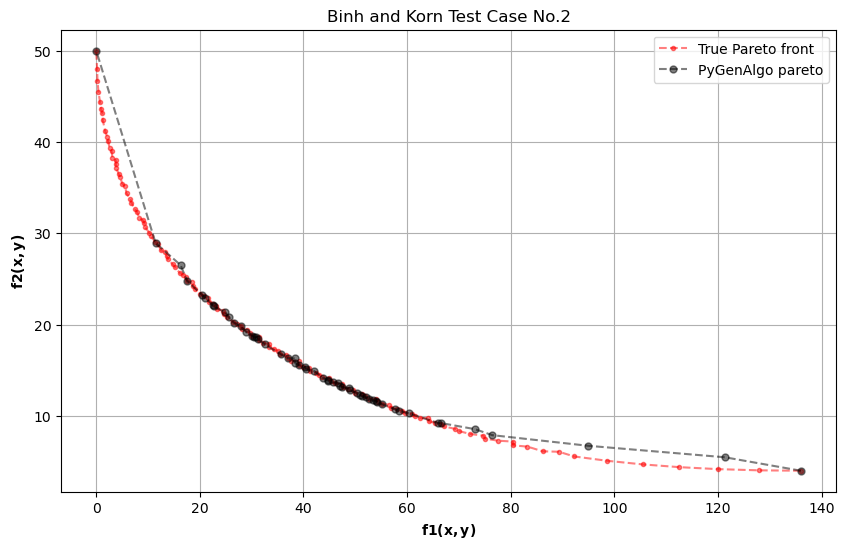

In [9]:
# Create a new figure.
plt.figure(figsize=(10, 6))

# Plot the Pareto front.
plt.plot(true_pareto[:, 0],
         true_pareto[:, 1],
         'r.--', alpha=0.5, label="True Pareto front")

# Plot the Pareto best_n.
plt.plot(pareto_best_n[:, 0],
         pareto_best_n[:, 1], "ko--", alpha=0.5,
         markersize=5, label="PyGenAlgo pareto")

# Tidy up the plot.
plt.title("Binh and Korn Test Case No.2")
plt.xlabel(r"$\mathbf{f1(x,y)}$")
plt.ylabel(r"$\mathbf{f2(x,y)}$")
plt.legend()
plt.grid(True)

plt.savefig("Binh_and_Korn_pareto.pdf", format="pdf", dpi=300)

### End of file